# Distance Metrics and Cannot-Link Constraints

The ``fast_hdbscan`` library supports arbitrary distance metrics via ``pynndescent``, and cannot-link constraints
that prevent specific pairs of points from ending up in the same cluster. These two features compose cleanly,
so you can use them independently or together. Let's load some libraries and get started:

In [1]:
import numpy as np
import fast_hdbscan

import scipy.sparse as sp
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs

sns.set(rc={"figure.figsize":(8,8)})

## Distance metrics

By default ``fast_hdbscan`` uses Euclidean distance with an optimised KD-tree implementation. However, Euclidean
distance isn't always the best choice. If your data lives on a sphere, or if you care about the angle between
vectors rather than their magnitude, you'll want a different metric.

Any metric supported by [pynndescent](https://pynndescent.readthedocs.io/) can be used by passing the ``metric``
parameter. Let's generate some data and try a few:

<Axes: >

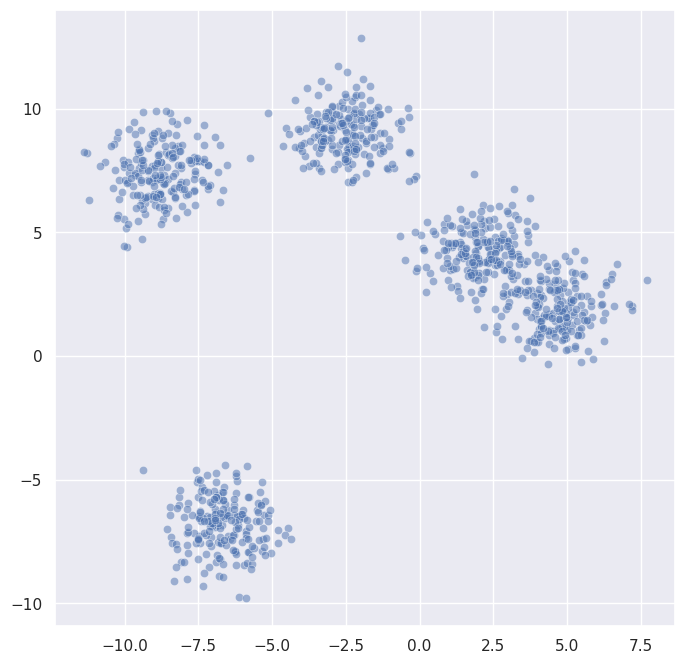

In [2]:
data, _ = make_blobs(n_samples=1000, n_features=2, centers=5, random_state=42, cluster_std=1.0)
sns.scatterplot(x=data.T[0], y=data.T[1], alpha=0.5)

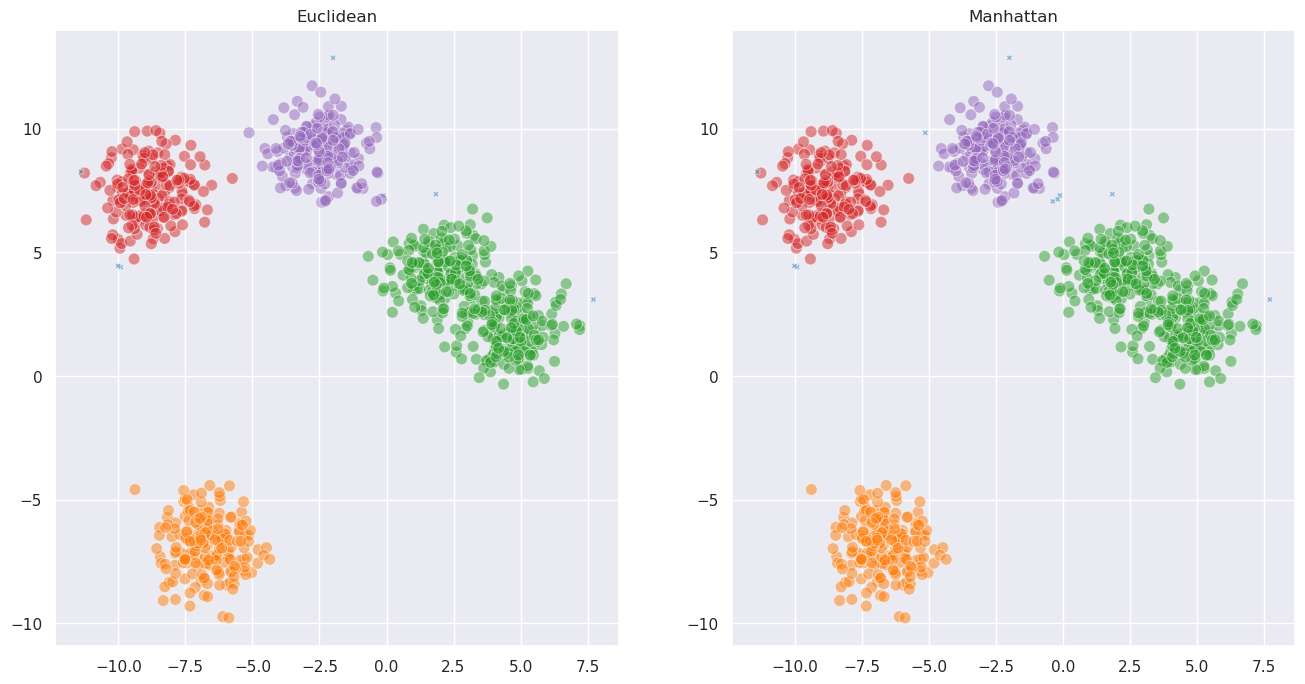

In [3]:
labels_euclidean = fast_hdbscan.HDBSCAN(min_cluster_size=15).fit_predict(data)
labels_manhattan = fast_hdbscan.HDBSCAN(min_cluster_size=15, metric="manhattan").fit_predict(data)

fig, axes = plt.subplots(1, 2, figsize=(16, 8))
for ax, labels, title in zip(
    axes,
    [labels_euclidean, labels_manhattan],
    ["Euclidean", "Manhattan"],
):
    sns.scatterplot(
        x=data.T[0], y=data.T[1], alpha=0.5,
        hue=labels, style=labels < 0, size=labels < 0,
        palette="tab10", legend=False, ax=ax,
    )
    ax.set_title(title)

For well-separated blobs the choice of metric doesn't matter much. Where it really makes a difference is when the
structure of your data is better captured by a different notion of distance. For example, cosine distance is useful
when the direction of a vector matters more than its magnitude:

<Axes: >

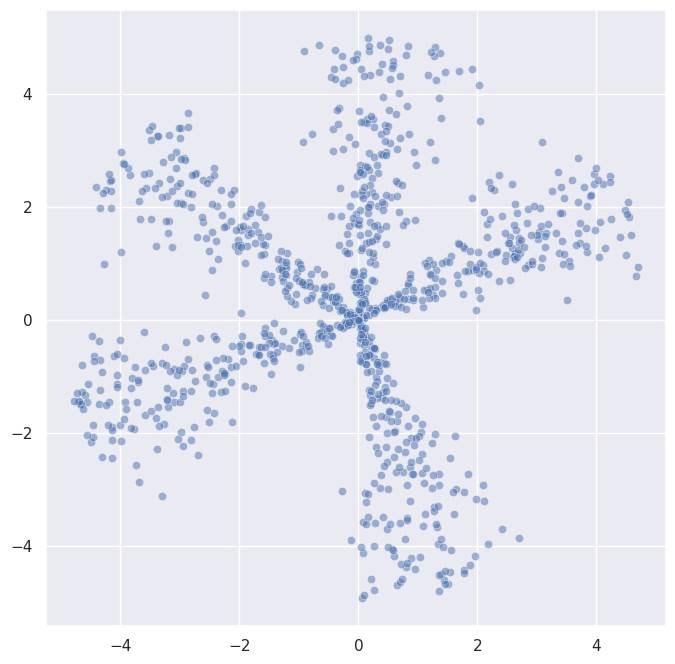

In [4]:
# Generate directional data: points spread along different angles
rng = np.random.RandomState(0)
angles = [0.5, 1.5, 2.5, 3.5, 5.0]
directional_data = []
for angle in angles:
    n = 200
    radii = rng.uniform(0, 5, size=n)
    noise = rng.normal(0, 0.15, size=n)
    x = radii * np.cos(angle + noise)
    y = radii * np.sin(angle + noise)
    directional_data.append(np.column_stack([x, y]))
directional_data = np.vstack(directional_data)

sns.scatterplot(x=directional_data.T[0], y=directional_data.T[1], alpha=0.5)

This data has clusters that radiate outward from the origin -- they're separated by angle, not by distance. Let's see how Euclidean and cosine clustering compare:

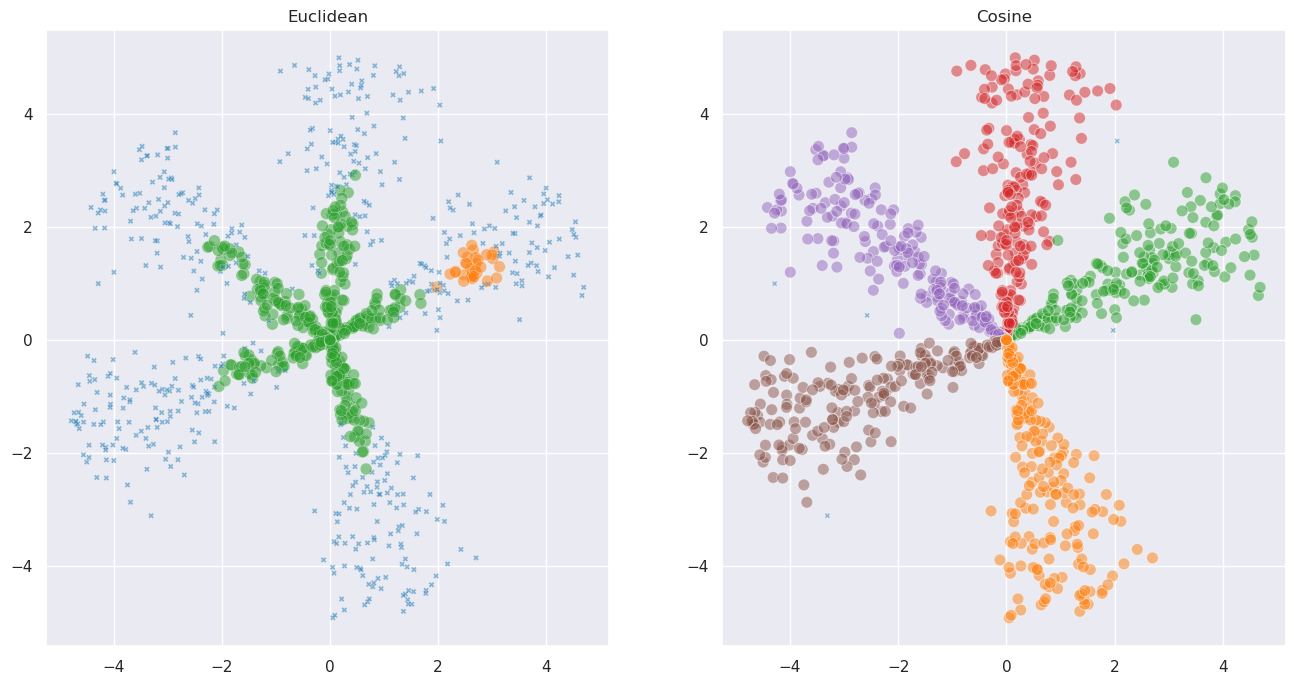

In [5]:
labels_euc = fast_hdbscan.HDBSCAN(min_cluster_size=30).fit_predict(directional_data)
labels_cos = fast_hdbscan.HDBSCAN(min_cluster_size=30, metric="cosine").fit_predict(directional_data)

fig, axes = plt.subplots(1, 2, figsize=(16, 8))
for ax, labels, title in zip(
    axes,
    [labels_euc, labels_cos],
    ["Euclidean", "Cosine"],
):
    sns.scatterplot(
        x=directional_data.T[0], y=directional_data.T[1], alpha=0.5,
        hue=labels, style=labels < 0, size=labels < 0,
        palette="tab10", legend=False, ax=ax,
    )
    ax.set_title(title)

Cosine distance captures the angular structure that Euclidean distance misses.

You can also pass extra keyword arguments to the metric function via ``metric_kwds``. For example, you can use the Minkowski distance with a custom exponent:

<Axes: >

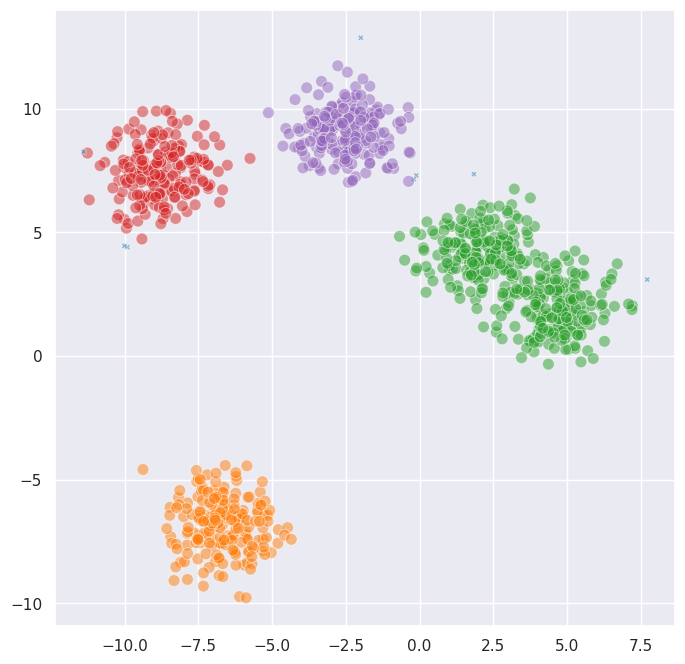

In [6]:
labels_minkowski = fast_hdbscan.HDBSCAN(
    min_cluster_size=15, metric="minkowski", metric_kwds={"p": 3}
).fit_predict(data)

sns.scatterplot(
    x=data.T[0], y=data.T[1], alpha=0.5,
    hue=labels_minkowski, style=labels_minkowski < 0, size=labels_minkowski < 0,
    palette="tab10", legend=False,
)

Some commonly useful metrics include:

- ``euclidean`` -- the default; good for low-dimensional spatial data
- ``manhattan`` -- L1 distance; more robust to outliers in individual dimensions
- ``cosine`` -- angular distance; useful when direction matters more than magnitude
- ``minkowski`` -- generalised Lp distance; use with ``metric_kwds={'p': ...}``
- ``chebyshev`` -- L-infinity distance; the maximum difference along any dimension
- ``correlation`` -- like cosine but centred; useful for comparing profiles
- ``haversine`` -- great-circle distance on a sphere; useful for geographic data
- ``hamming``, ``jaccard`` -- useful for binary or categorical features

Any metric supported by ``pynndescent`` will work, including custom callables. You can also control the size of the nearest neighbour graph used internally via the ``knn_k`` parameter; larger values can improve accuracy at the cost of speed.

## Cannot-link constraints

Sometimes you have prior knowledge that certain pairs of points should *not* end up in the same cluster. For
example, you might know that two items belong to different categories, or have domain-specific reasons to keep
them apart. Cannot-link constraints let you encode this knowledge directly into the clustering process.

To demonstrate, let's build a case where HDBSCAN gets it wrong without help. We'll generate two Gaussian blobs
that are close enough to overlap:

<Axes: >

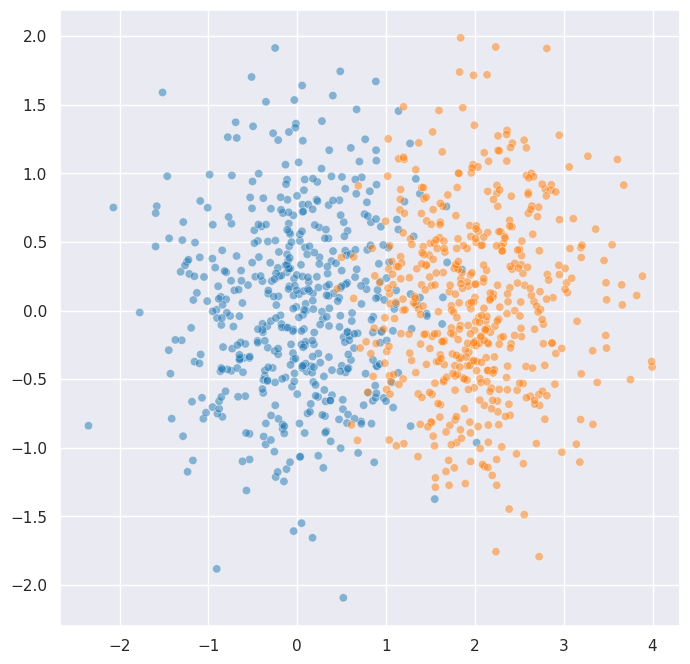

In [7]:
rng = np.random.RandomState(8)
blob_a = rng.normal(loc=[0, 0], scale=0.66, size=(500, 2))
blob_b = rng.normal(loc=[2.0, 0], scale=0.66, size=(500, 2))
overlap_data = np.vstack([blob_a, blob_b])
true_labels = np.array([0] * 500 + [1] * 500)

sns.scatterplot(
    x=overlap_data.T[0], y=overlap_data.T[1], alpha=0.5,
    hue=true_labels, palette="tab10", legend=False,
)

These two blobs overlap significantly. Let's see what HDBSCAN does without any constraints:

<Axes: >

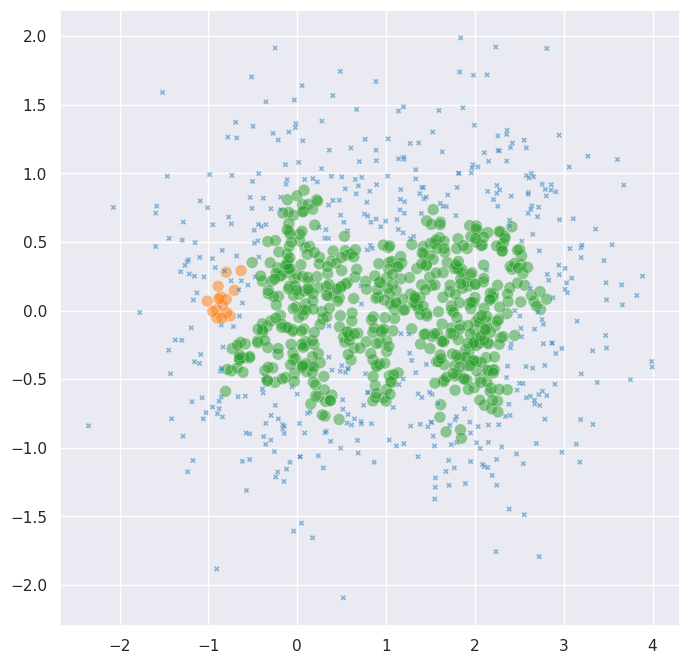

In [8]:
unconstrained_labels = fast_hdbscan.HDBSCAN(
    min_cluster_size=10, algorithm="kruskal"
).fit_predict(overlap_data)

sns.scatterplot(
    x=overlap_data.T[0], y=overlap_data.T[1], alpha=0.5,
    hue=unconstrained_labels, style=unconstrained_labels < 0, size=unconstrained_labels < 0,
    palette="tab10", legend=False,
)

As expected, HDBSCAN merges the two blobs into a single cluster -- the density bridge between them is too strong
to break on its own. But suppose we know that a handful of points from blob A and blob B are definitely in
different groups. We can add cannot-link constraints to force the clustering to respect this knowledge.

We encode constraints as a sparse matrix of shape ``(n_samples, n_samples)`` where any non-zero entry ``(i, j)``
means point ``i`` and point ``j`` must not be in the same cluster:

In [9]:
# Pick a few points we "know" are in different groups
# Points 0-499 are from blob A, points 500-999 are from blob B
constraint_pairs_a = [0, 100, 200, 300, 400]        # 5 points from blob A
constraint_pairs_b = [500, 600, 700, 800, 900]  # 5 points from blob B

# Create a sparse constraint matrix
rows = constraint_pairs_a + constraint_pairs_b
cols = constraint_pairs_b + constraint_pairs_a
values = np.ones(len(rows))
n = len(overlap_data)
constraints = sp.csr_matrix((values, (rows, cols)), shape=(n, n))

print(f"Number of constraint pairs: {len(constraint_pairs_a)}")
print(f"Total data points: {n}")

Number of constraint pairs: 5
Total data points: 1000


Now let's cluster with the constraints. Cannot-link constraints require ``algorithm='kruskal'``:

<Axes: >

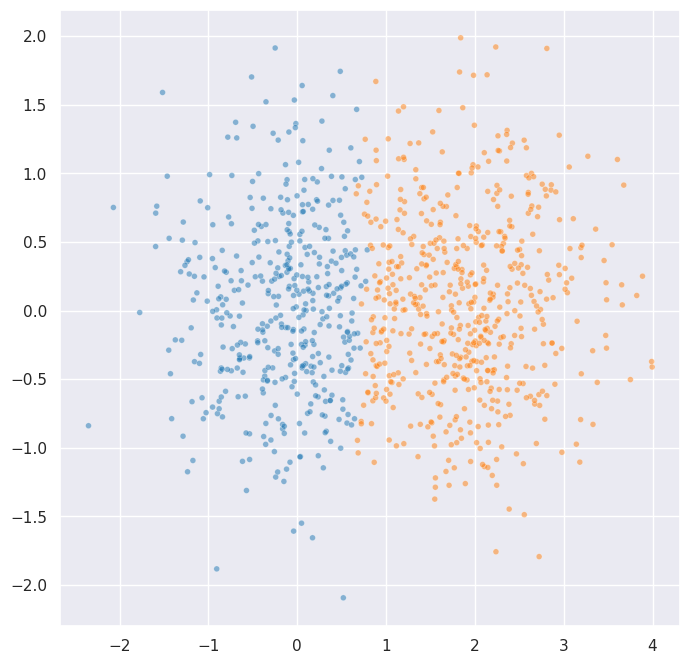

In [10]:
constrained_labels = fast_hdbscan.HDBSCAN(
    min_cluster_size=10,
    algorithm="kruskal",
    cannot_link=constraints,
).fit_predict(overlap_data)

sns.scatterplot(
    x=overlap_data.T[0], y=overlap_data.T[1], alpha=0.5,
    hue=constrained_labels, style=constrained_labels < 0, size=constrained_labels < 0,
    palette="tab10", legend=False,
)

It only took 5 constraint pairs to resolve the ambiguity. The constraints work by blocking edges in the minimum spanning tree that would merge components containing constrained points. This blocking is transitive: if point 0 and point 200 are constrained, then *any* merge that would put them in the same component is blocked -- not just the direct edge between them.

### Building constraint matrices

Constraints are provided as a scipy sparse matrix. You can build them in whatever sparse format is most convenient:

```python
# From COO format
constraints = sp.coo_matrix((values, (rows, cols)), shape=(n, n))

# From CSR format
constraints = sp.csr_matrix((values, (rows, cols)), shape=(n, n))

# Upper-triangle only -- auto-symmetrized by default
constraints = sp.csr_matrix((values, (rows, cols)), shape=(n, n))
```

The ``validate_cannot_link`` parameter (default ``True``) automatically converts your input to symmetric CSR format. This means you only need to provide one direction of each constraint pair -- the symmetrization is handled for you. If you have a very large constraint matrix that you've already symmetrised, you can set ``validate_cannot_link=False`` to skip this step.

## Combining metrics and constraints

These two features compose naturally. Let's use cosine distance together with cannot-link constraints on our directional data:

<Axes: >

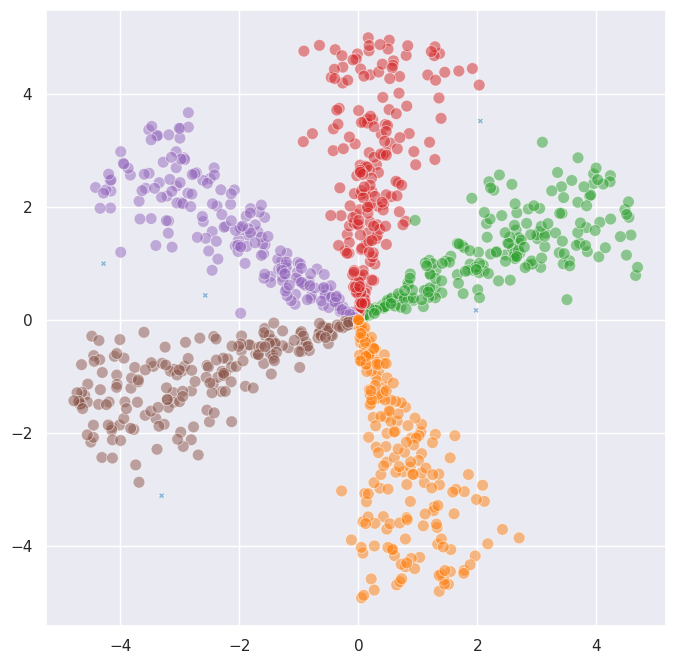

In [11]:
# Add some cannot-link constraints between adjacent angular clusters
# to sharpen the boundaries
cos_constraint_rows = [0, 1, 2]      # points from angular cluster 0
cos_constraint_cols = [200, 201, 202] # points from angular cluster 1
cos_rows = cos_constraint_rows + cos_constraint_cols
cos_cols = cos_constraint_cols + cos_constraint_rows
cos_values = np.ones(len(cos_rows))
cos_constraints = sp.csr_matrix(
    (cos_values, (cos_rows, cos_cols)), shape=(len(directional_data), len(directional_data))
)

combined_labels = fast_hdbscan.HDBSCAN(
    min_cluster_size=30,
    metric="cosine",
    algorithm="kruskal",
    cannot_link=cos_constraints,
).fit_predict(directional_data)

sns.scatterplot(
    x=directional_data.T[0], y=directional_data.T[1], alpha=0.5,
    hue=combined_labels, style=combined_labels < 0, size=combined_labels < 0,
    palette="tab10", legend=False,
)

The metric controls how distances are computed, and the constraints control which merges are allowed. They operate at different stages of the algorithm and combine without any special handling.

In summary: use alternative distance metrics when Euclidean distance doesn't capture the structure of your data, and add cannot-link constraints when you have prior knowledge about which points should be kept apart. Together, these features make ``fast_hdbscan`` considerably more flexible.